In [1]:
from datetime import datetime
import pandas as pd
import matplotlib.dates as mdates
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from meteostat import Point, Hourly, Stations
from tqdm import tqdm
import sys
import numpy as np

In [2]:
sys.path.append('Utils/')
from PlotUtils import setMplParam, getColour, getHistoParam 
# getHistoParam: 
# Nbins, binwidth, bins, counts, bin_centers  = 
# from ExternalFunctions import nice_string_output, add_text_to_ax
setMplParam()
from DataPipelineWorkShop import get_hourly_example, MeteoPreprocessor


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/yhjo/miniconda3/envs/tempestransformer/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/yhjo/miniconda3/envs/tempestransformer/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/yhjo/miniconda3/envs/tempestransformer/lib/python3.12/site-packages/ipykernel/kernelapp

In [3]:
def make_single_window_dataframe(location: Point, 
                                 start_time: datetime, 
                                 horizon_hours: int) -> pd.DataFrame:
    """
    Construct a minimal Meteostat dataframe covering exactly one forecasting window.

    Args:
        location (Point): Meteostat location object.
        start_time (datetime): End of the observation window (the forecast will start right after this).
        exp_ctx (ExperimentContext): Contains forecast.window and forecast.horizon.
    """

    # Fetch data covering just enough history for one forecast
    history_end  = start_time + pd.Timedelta(hours=horizon_hours)

    df = get_hourly_example(location, start_time, history_end)
    df = df[df.index < history_end]

    # Defensive timestamp conversion
    if isinstance(df.index, pd.PeriodIndex):
        df.index = df.index.to_timestamp()

    return df

In [4]:
kbh = Point(lat=55.6761, lon=12.5683)
start_time = datetime(2019, 6, 3, 0, 0)
df_true = make_single_window_dataframe(kbh, start_time, horizon_hours=12)

In [5]:
df_true.columns

Index(['temp', 'dwpt', 'rhum', 'prcp', 'snow', 'wdir', 'wspd', 'wpgt', 'pres',
       'tsun', 'coco'],
      dtype='object')

In [6]:
df_true[['temp', 'rhum', 'prcp', 'wdir', 'wspd']]

,temp,rhum,prcp,wdir,wspd
time,,,,,
2019-06-03 00:00:00,16.0,71.0,0.0,130.0,25.9
2019-06-03 01:00:00,15.7,77.0,<NA>,140.0,27.7
2019-06-03 02:00:00,16.3,81.0,<NA>,140.0,22.3
2019-06-03 03:00:00,16.1,82.0,<NA>,150.0,16.6
2019-06-03 04:00:00,15.9,84.0,<NA>,150.0,11.2
2019-06-03 05:00:00,17.4,78.0,<NA>,200.0,11.2
2019-06-03 06:00:00,17.4,78.0,0.0,190.0,13.0
2019-06-03 07:00:00,18.9,74.0,<NA>,190.0,16.6
2019-06-03 08:00:00,20.5,71.0,<NA>,180.0,13.0


In [7]:
base = "/Users/yhjo/Desktop/[2025] Be Resilient/Resilience/"
# base="C:/Users/yhjo7/Meteoformer/MeteoFormer/"

In [8]:
prediction_files = {
    # "b256_d64_h2_l2_win24_ho12_lr1e-4" : base+"logs/20251110/153321/predictions/20251113_131644_epochepoch-19-val_lossval_loss-0.1044.csv",
    # "b256_d64_h2_l4_win24_ho12_lr1e-4" : base+"logs/20251110/141108/predictions/20251113_130918_epochepoch-19-valloss-0.1025.csv",
    # "b512_d64_h2_l4_win24_ho12_lr1e-4": base+"prediction/20251114/132736/20251114_144422_epoch-19-val_loss-0.1254.csv",
    # "b512_d64_h2_l4_win24_ho12_lr3e-4": base+"prediction/20251114/144305/20251114_180636_epoch-16-val_loss-0.0983.csv",
    # "b512_d64_h2_l4_win24_ho12_lr5e-4" : base+"prediction/20251114/114050/20251114_124824_epoch-15-val_loss-0.0957.csv",
    # "b512_d64_h2_l4_win24_ho12_lr7.5e-4" : base+"prediction/20251114/123713/20251114_132744_epoch-10-val_loss-0.0958.csv",
    "b512_d64_h2_l4_win72_ho12_lr3e-4_100": base+"prediction/20251116/014137/20251117_123811_epoch-13-val_loss-0.0811.csv",
    "b512_d64_h2_l4_win72_ho12_lr3e-4_100_last": base+"prediction/20251116/014137/20251117_123835_last.csv",
    "b512_d64_h2_l4_win72_ho12_lr3e-4_50": base+"prediction/20251116/201436/20251117_125436_epoch-27-val_loss-0.0836.csv",
    "b512_d64_h2_l4_win72_ho12_lr3e-4_50_last": base+"prediction/20251116/201436/20251117_125508_last.csv",
    
}

In [9]:
prediction_files_eftermiddag = {
    "b512_d64_h2_l4_win72_ho12_lr3e-4_100": base+"prediction/20251116/201436/20251117_143729_epoch-27-val_loss-0.0836(20190603_1200).csv",
    "b512_d64_h2_l4_win72_ho12_lr3e-4_100_last": base+"prediction/20251116/201436/20251117_143747_last(20190603_1200).csv",
    "b512_d64_h2_l4_win72_ho12_lr3e-4_50": base+"prediction/20251116/014137/20251117_144006_epoch-13-val_loss-0.0811(20190603_1200).csv",
    "b512_d64_h2_l4_win72_ho12_lr3e-4_50_last": base+"prediction/20251116/014137/20251117_144030_last(20190603_1200).csv"
    }

In [10]:
prediction_files_therm = {
    "b512_d256_h2_l4_win72_ho12_lr3e-4_9": base+"prediction/20251118/191554/20251118_205256_epoch-09-val_loss-0.0174(20190603_0000).csv",
    "b512_d256_h2_l4_win72_ho12_lr3e-4_50": base+"prediction/20251118/191554/20251118_205257_last(20190603_0000).csv"
}


In [11]:

prediction_files_eftermiddag_therm = {
    "b512_d256_h2_l4_win72_ho12_lr3e-4_9": base+"prediction/20251118/191554/20251118_195052_epoch-09-val_loss-0.0174(20190603_1200).csv",
    "b512_d256_h2_l4_win72_ho12_lr3e-4_50": base+"prediction/20251118/191554/20251118_195053_last(20190603_1200).csv",
    }
    

In [12]:
# prediction_files_dec = {
#     "b512_d64_h2_l4_win72_ho12_lr3e-4_100": base+"prediction/20251116/014137/20251117_142939_epoch-13-val_loss-0.0811(20191203_0000).csv",
#     "b512_d64_h2_l4_win72_ho12_lr3e-4_100_last": base+"prediction/20251116/014137/20251117_143018_last(20191203_0000).csv",
#     "b512_d64_h2_l4_win72_ho12_lr3e-4_50": base+"prediction/20251116/201436/20251117_143310_epoch-27-val_loss-0.0836(20191203_0000).csv",
#     "b512_d64_h2_l4_win72_ho12_lr3e-4_50_last": base+"prediction/20251116/201436/20251117_143338_last(20191203_0000).csv",
# }

In [13]:
prediction_files_wind = {
    "b512_d256_h2_l4_win72_ho12_lr3e-4_4": base+"prediction/20251119/092637/20251119_094924_epoch-04-val_loss-0.2356(20190603_0000).csv",
}
prediction_files_eftermiddag_wind = {
    "b512_d256_h2_l4_win72_ho12_lr3e-4_4": base+"prediction/20251119/092637/20251119_095113_epoch-04-val_loss-0.2356(20190603_1200).csv",
}

In [14]:
# df_pred = pd.read_csv(prediction_files["b256_d64_h2_l4_win24_ho12_lr1e-4"])
# df_pred.columns

In [15]:
processor = MeteoPreprocessor()
# df_pred_inv = processor.inverse_transform(df_pred)

In [16]:
# df_pred_inv

In [17]:
def plot_hourly_features(
    df_true: pd.DataFrame,
    df_pred: pd.DataFrame,
    features: list[str],
    titles: list[str] = None
) -> None:
    # --- normalise time index for df_true ---
    if 'time' in df_true.columns:
        df_true['time'] = pd.to_datetime(df_true['time'])
        df_true = df_true.set_index('time')
    elif isinstance(df_true.index, pd.PeriodIndex):
        df_true.index = df_true.index.to_timestamp()

    # --- normalise time index for df_pred ---
    if 'time' in df_pred.columns:
        df_pred['time'] = pd.to_datetime(df_pred['time'])
        df_pred = df_pred.set_index('time')
    elif isinstance(df_pred.index, pd.PeriodIndex):
        df_pred.index = df_pred.index.to_timestamp()

    n_features = len(features)
    fig, axes = plt.subplots(n_features, 1, figsize=(19, 5*n_features), sharex=True)
    if n_features == 1:
        axes = [axes]
        
    for i, ax, feature in zip(range(n_features), axes, features):
        df_true[feature].plot(ax=ax, label="True")
        df_pred[feature].plot(ax=ax, label="Predicted", color=getColour(i+1))
        ax.set_title(
            titles[i] if titles is not None else feature
        )
        ax.set_ylabel(feature)
        ax.legend()

    axes[-1].set_xlabel("Date")
    plt.tight_layout()
    plt.show()


# plot_hourly_features(df_true, df_pred_inv, 
#                      features=['temp', 'rhum', 'wspd', 'wdir'], 
#                      titles=['Temperature (°C)', 'Relative Humidity (%)', 'Wind Speed (km/h)', 'Wind Direction (°)'])

In [18]:
def compare_models_per_feature(
    prediction_files: dict[str, str],
    features: list[str] = ['temp', 'rhum', 'wspd', 'wdir'],
    titles: list[str] = None,
    horizon_hours: int = 12,
    location: tuple[float, float] = (55.6761, 12.5683),
    start_time: datetime = datetime(2019, 6, 3, 0, 0)
):

    # ------------------------------------------------------------
    # Load TRUE data
    # ------------------------------------------------------------
    lat, lon = location
    kbh = Point(lat=lat, lon=lon)
    df_true = make_single_window_dataframe(kbh, start_time, horizon_hours=horizon_hours)

    if "time" in df_true.columns:
        df_true["time"] = pd.to_datetime(df_true["time"])
        df_true = df_true.set_index("time")

    processor = MeteoPreprocessor()

    # ------------------------------------------------------------
    # Load MODEL predictions
    # ------------------------------------------------------------
    preds = {}
    for model_name, file_path in prediction_files.items():
        df_pred = pd.read_csv(file_path)
        df_pred = processor.inverse_transform(df_pred)

        if "time" in df_pred.columns:
            df_pred["time"] = pd.to_datetime(df_pred["time"])
            df_pred = df_pred.set_index("time")

        preds[model_name] = df_pred

    # ------------------------------------------------------------
    # Plot features
    # ------------------------------------------------------------
    for idx, feature in enumerate(features):

        # ==========================
        # SPECIAL CASE: WIND DIR
        # ==========================
        if feature == "wdir":
            times = df_true.index
            n_steps = len(times)

            # use integer positions for x (0,1,2,...) to avoid datetime scaling hell
            x_idx = np.arange(n_steps)

            num_models = len(preds) + 1  # True + models
            row_positions = np.arange(num_models)

            fig, ax = plt.subplots(figsize=(18, 4 + num_models * 1.0))

            def plot_direction_row(y, angles_deg, speeds, color, label=None):
                angles = np.deg2rad(angles_deg)

                # normalise windspeed to 0–1
                if speeds.max() > 0:
                    speeds_norm = speeds / speeds.max()
                else:
                    speeds_norm = speeds

                L_max = 0.6   # max arrow length in data coords

                for xi, ang, sn in zip(x_idx, angles, speeds_norm):
                    L = 0.1 + sn * L_max      # optional: small constant base (0.1)
                    dx = L * np.cos(ang)
                    dy = L * np.sin(ang)

                    arrow = FancyArrowPatch(
                        (xi, y),
                        (xi + dx, y + dy),
                        arrowstyle="-|>",
                        mutation_scale=15,
                        lw=1.3,
                        color=color
                    )
                    ax.add_patch(arrow)

                if label:
                    ax.plot([], [], color=color, label=label)

            # True at row 0
            # plot_direction_row(row_positions[0], df_true["wdir"].values, "black", "True")
            plot_direction_row(
                row_positions[0],
                df_true["wdir"].values,
                df_true["wspd"].values,
                "black",
                "True"
            )

            # Models at rows 1, 2, ...
            for i, (model_name, df_pred) in enumerate(preds.items(), start=1):
                # plot_direction_row(row_positions[i], df_pred["wdir"].values, getColour(i-1), model_name)
                plot_direction_row(
                    row_positions[i],
                    df_pred["wdir"].values,
                    df_pred["wspd"].values,
                    getColour(i-1),
                    model_name
                )

            # y-axis labels = True + model names
            ax.set_ylim(-1, num_models)
            ax.set_yticks(row_positions)
            ax.set_yticklabels(["True"] + list(preds.keys()))

            # x-axis: show times as tick labels
            ax.set_xticks(x_idx)
            ax.set_xticklabels(
                [t.strftime("%Y-%m-%d %H:%M") for t in times],
                rotation=45,
                ha="right"
            )

            ax.set_title("Wind Direction (Arrow Timeline)")
            ax.set_xlabel("Time")
            ax.grid(axis="x", linestyle="--", alpha=0.3)
            ax.invert_yaxis()

            plt.tight_layout()
            plt.show()

        # ==========================
        # NORMAL LINE PLOTS
        # ==========================
        fig, ax = plt.subplots(figsize=(18, 6))

        df_true[feature].plot(ax=ax, label="True", linewidth=2, color="black")
        for i, (model_name, df_pred) in enumerate(preds.items()):
            df_pred[feature].plot(ax=ax, label=model_name, color=getColour(i))

        ax.set_title(titles[idx] if titles else feature)
        ax.set_ylabel(feature)
        ax.set_xlabel("Date")
        ax.legend()
        plt.tight_layout()
        plt.show()


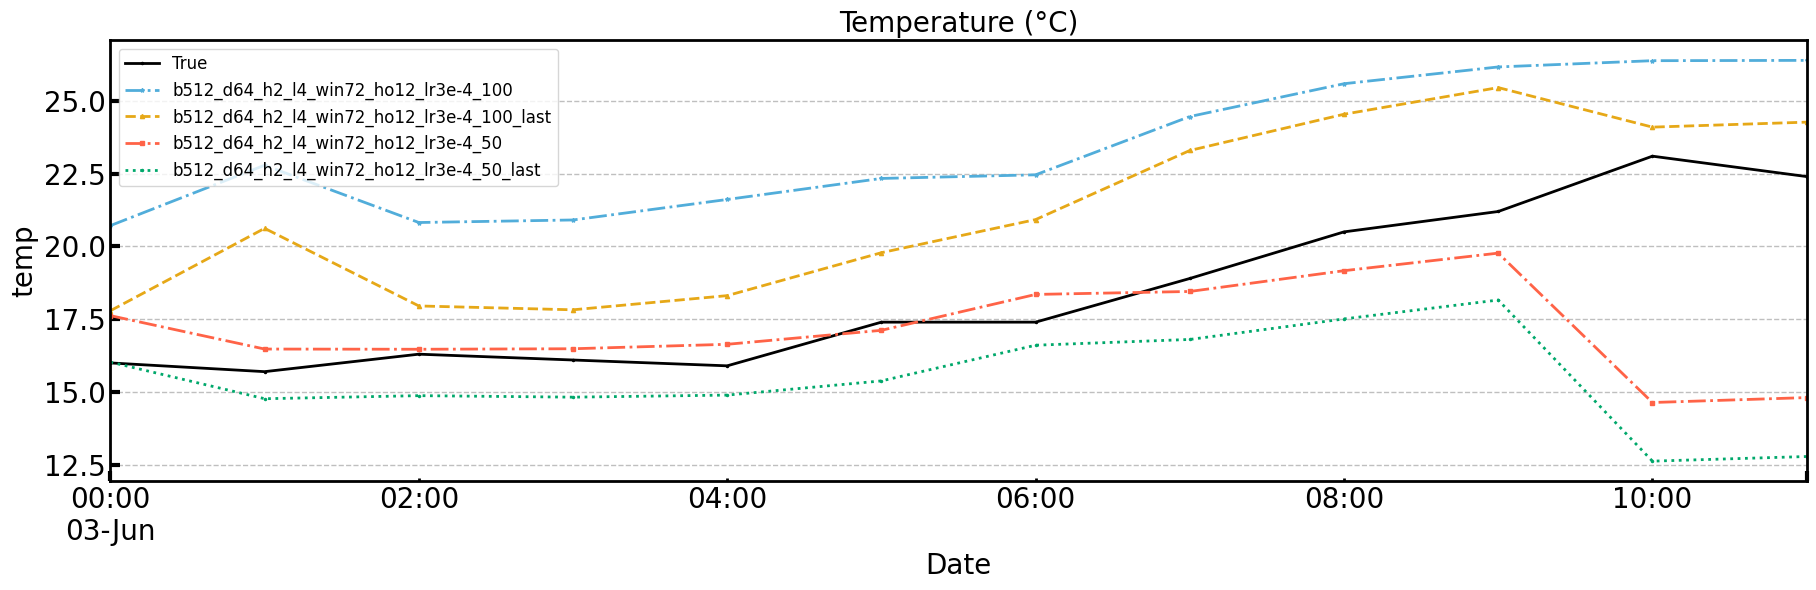

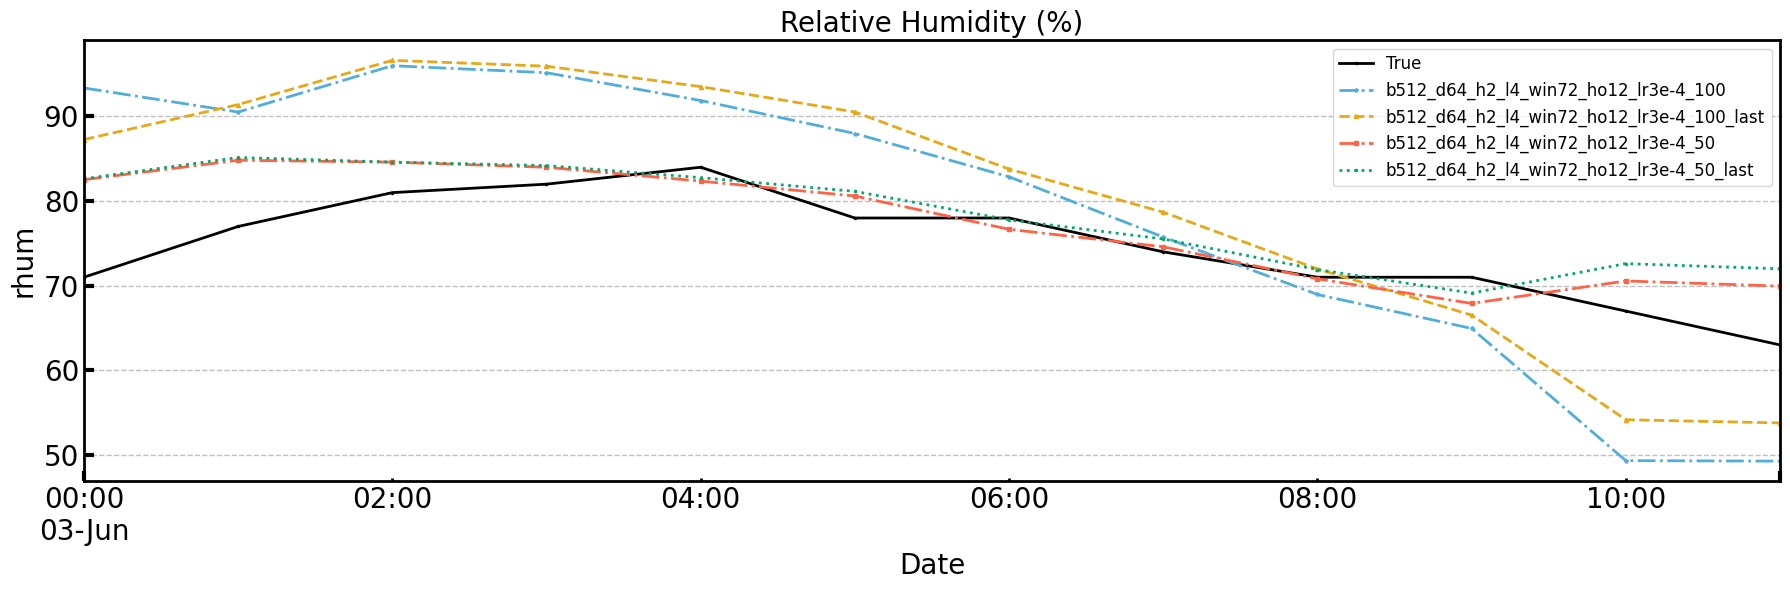

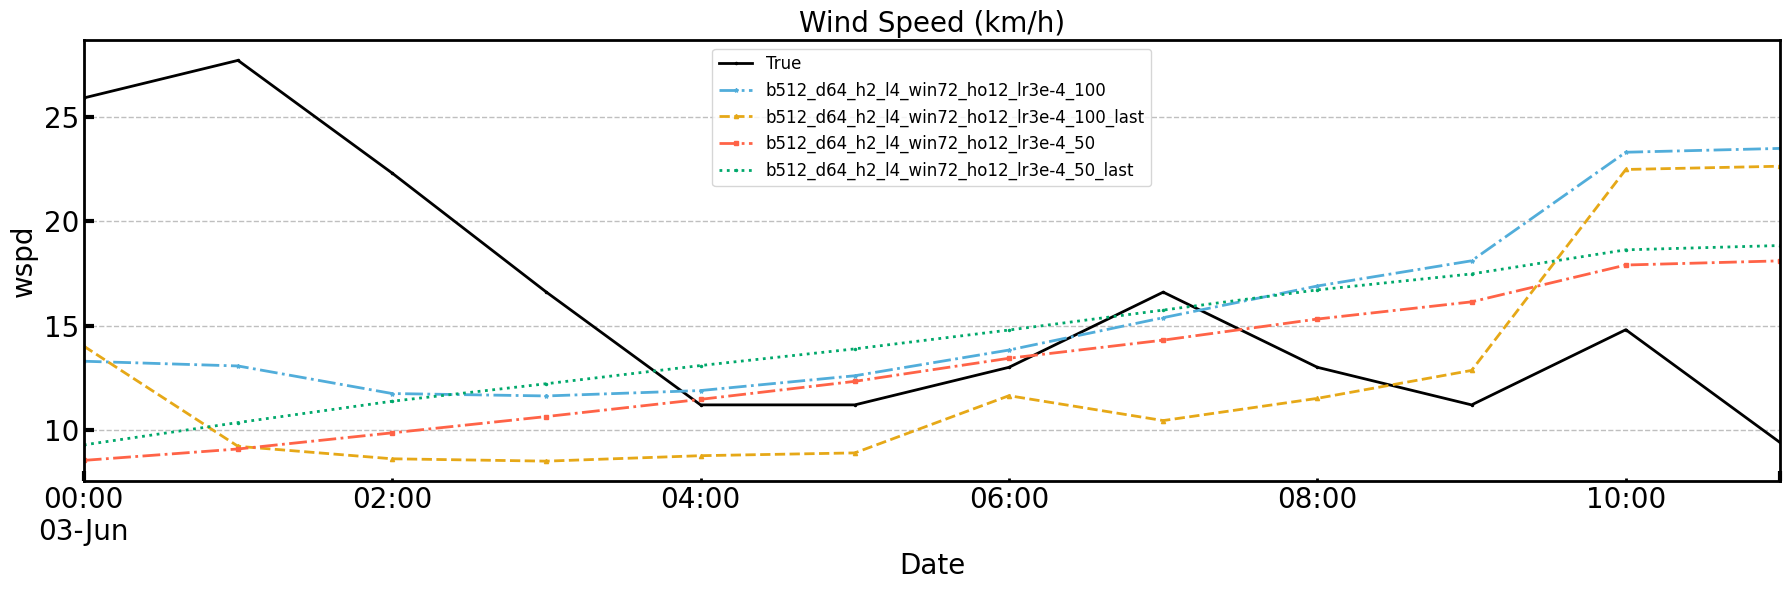

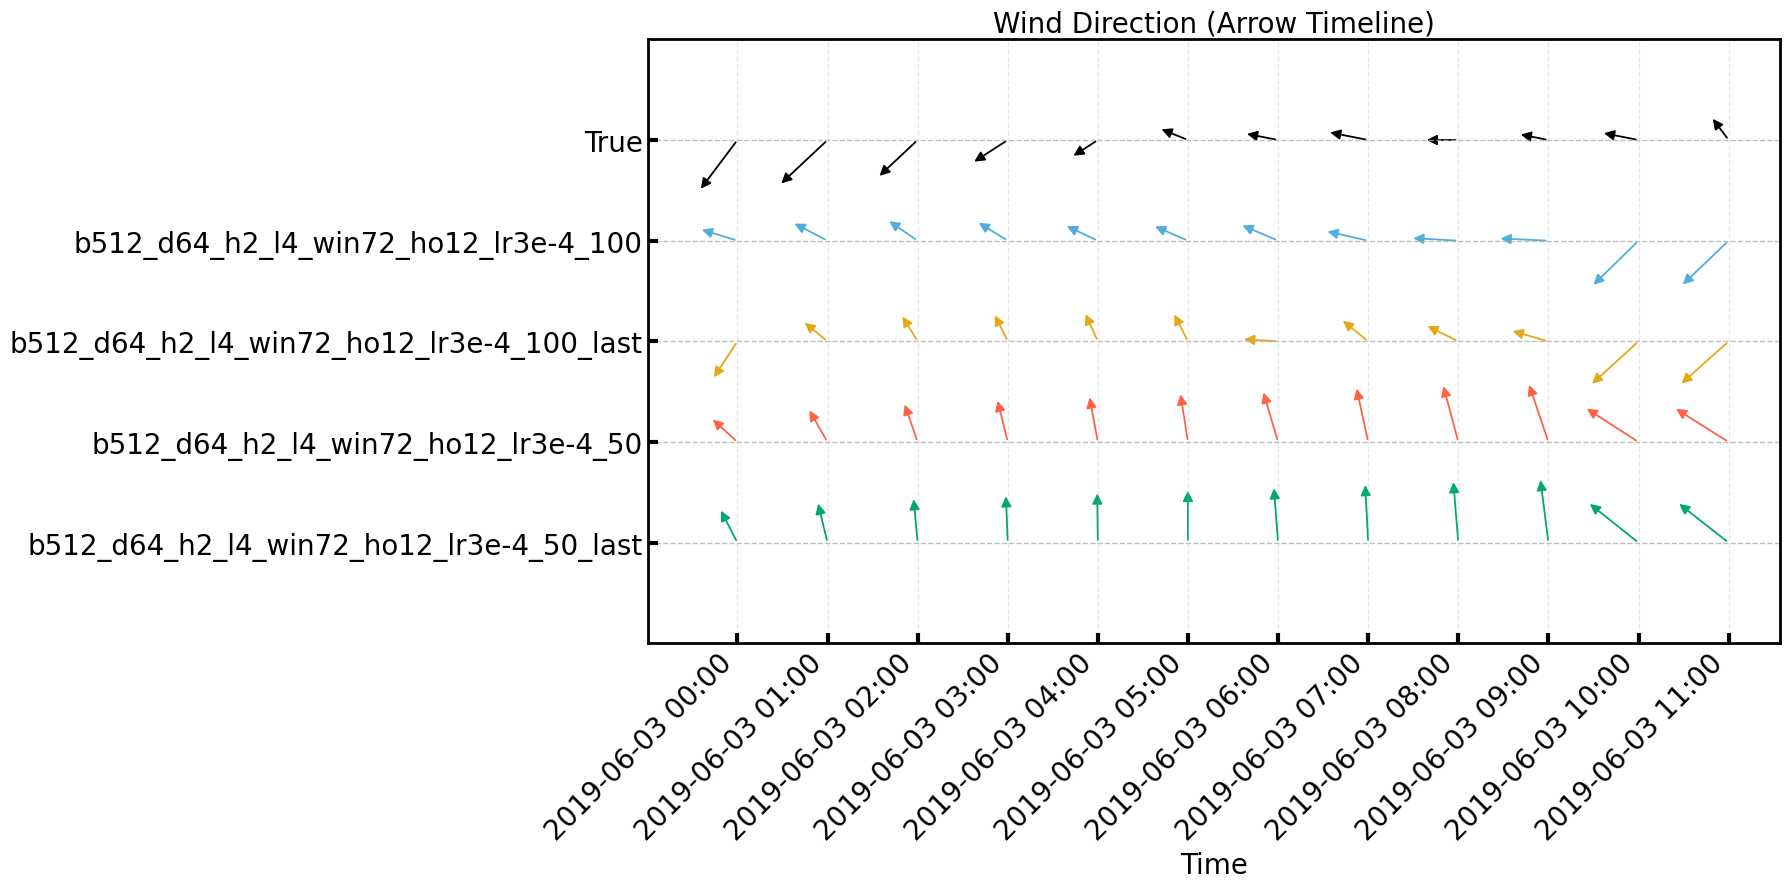

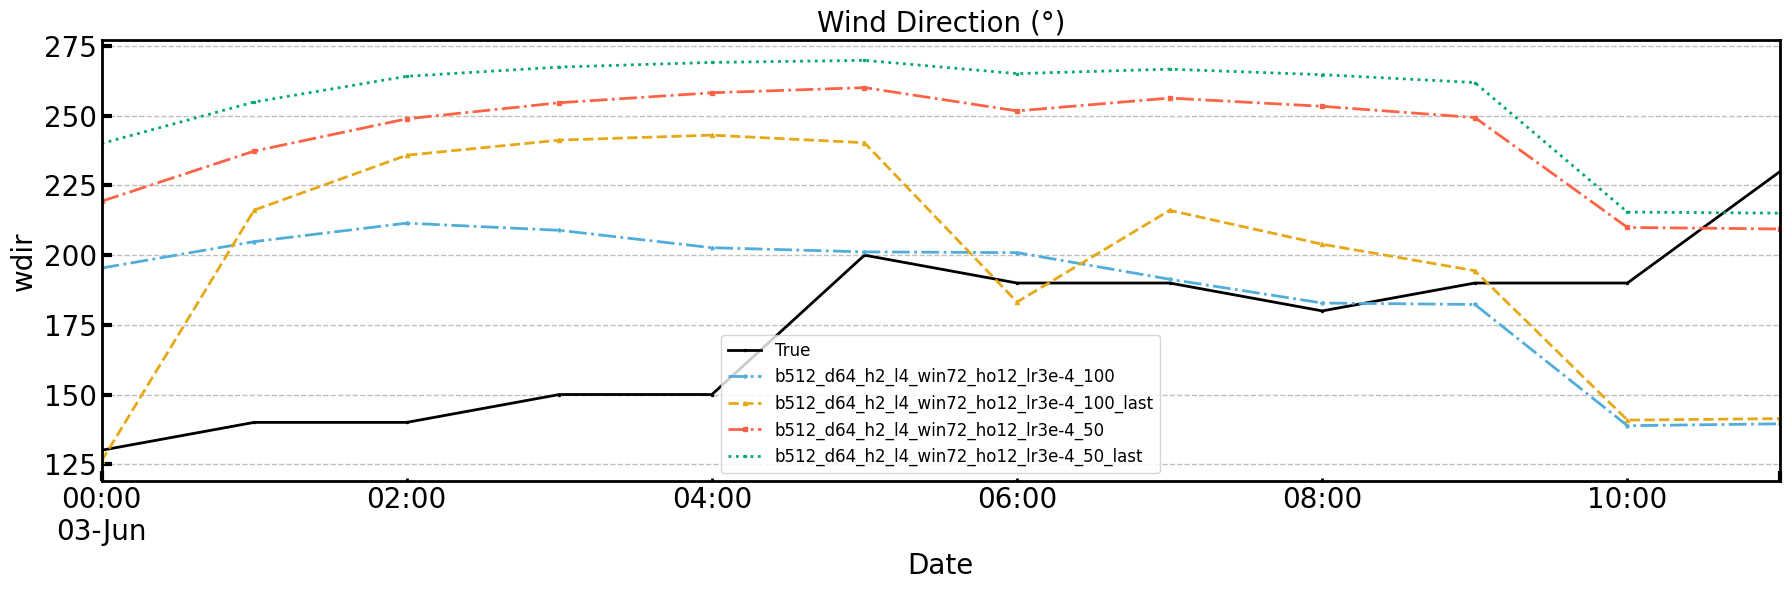

In [19]:
compare_models_per_feature(
    prediction_files,
    features=['temp', 'rhum', 'wspd', 'wdir'],
    titles=['Temperature (°C)', 'Relative Humidity (%)', 'Wind Speed (km/h)', 'Wind Direction (°)'],
    start_time=datetime(2019, 6, 3, 0, 0)
)

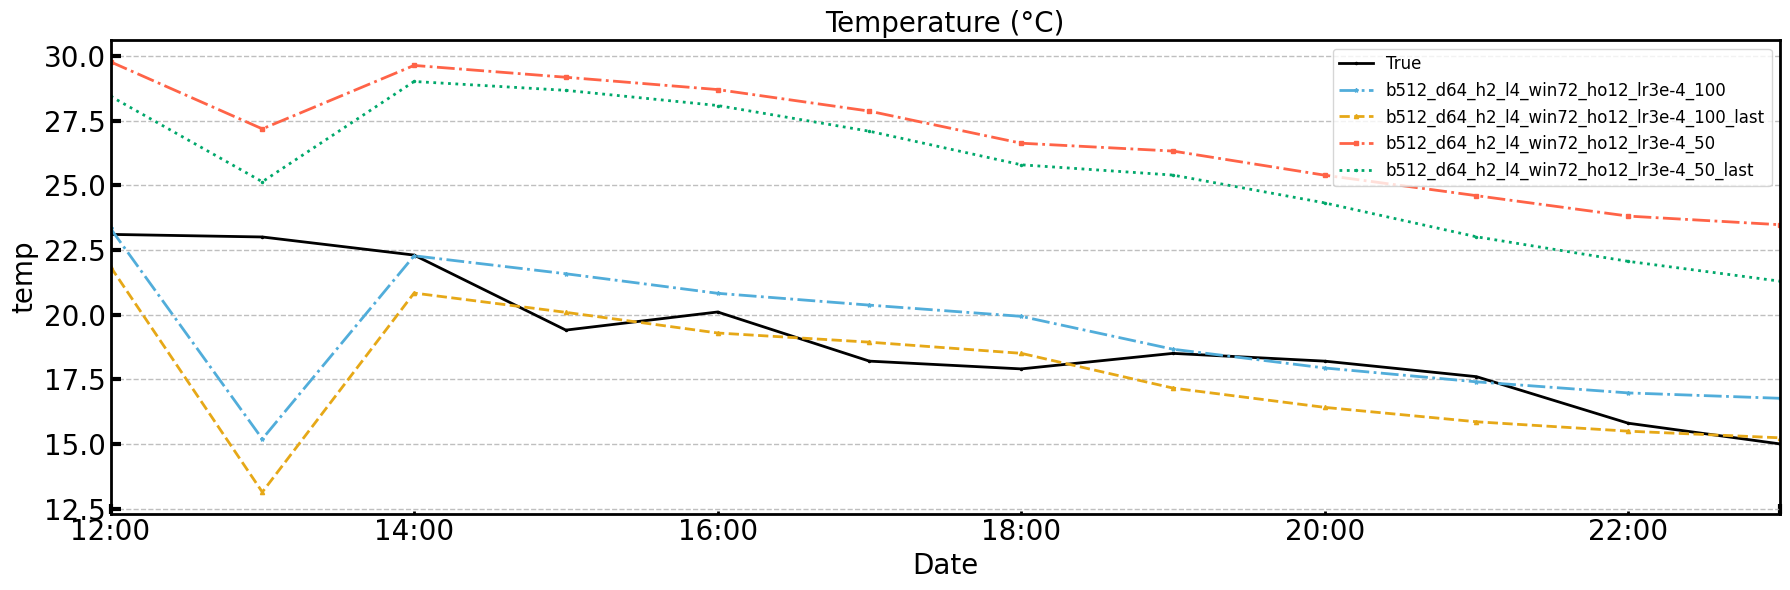

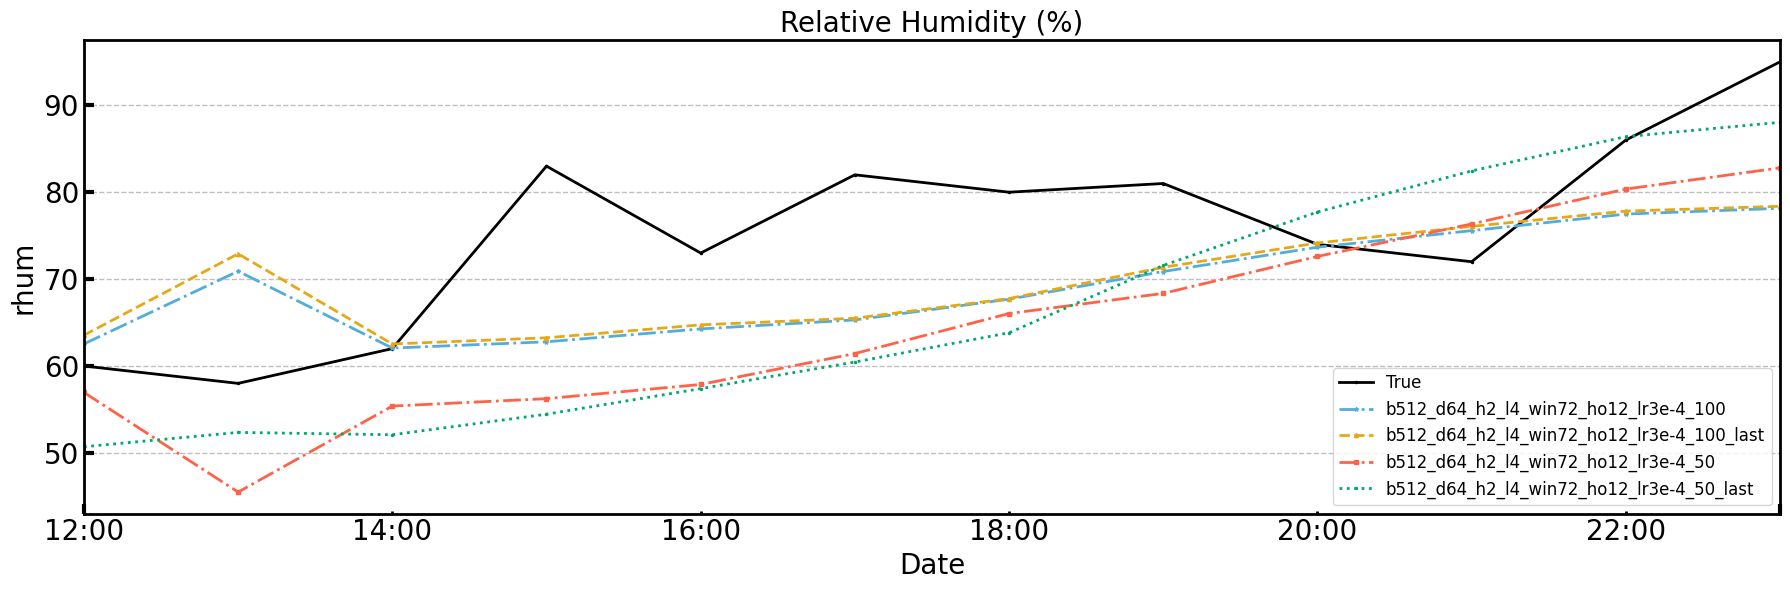

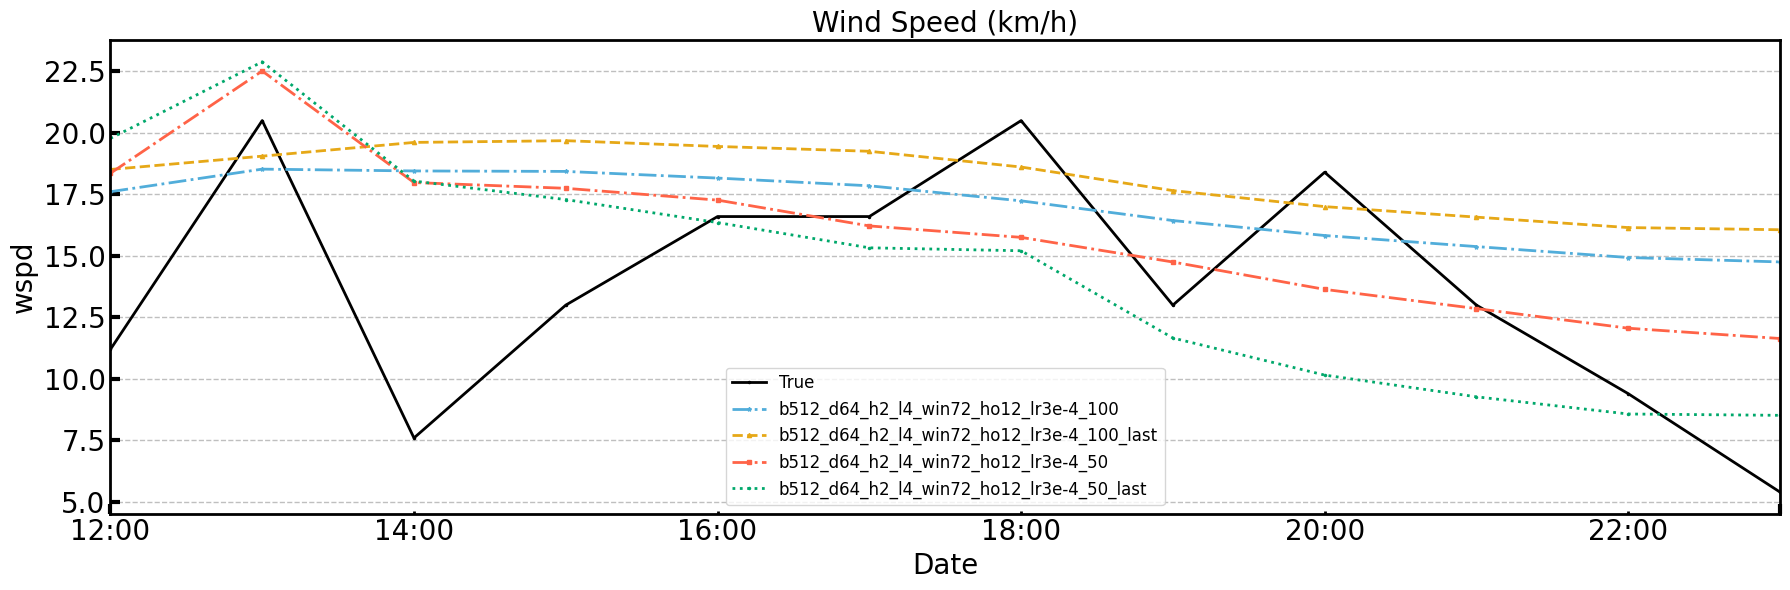

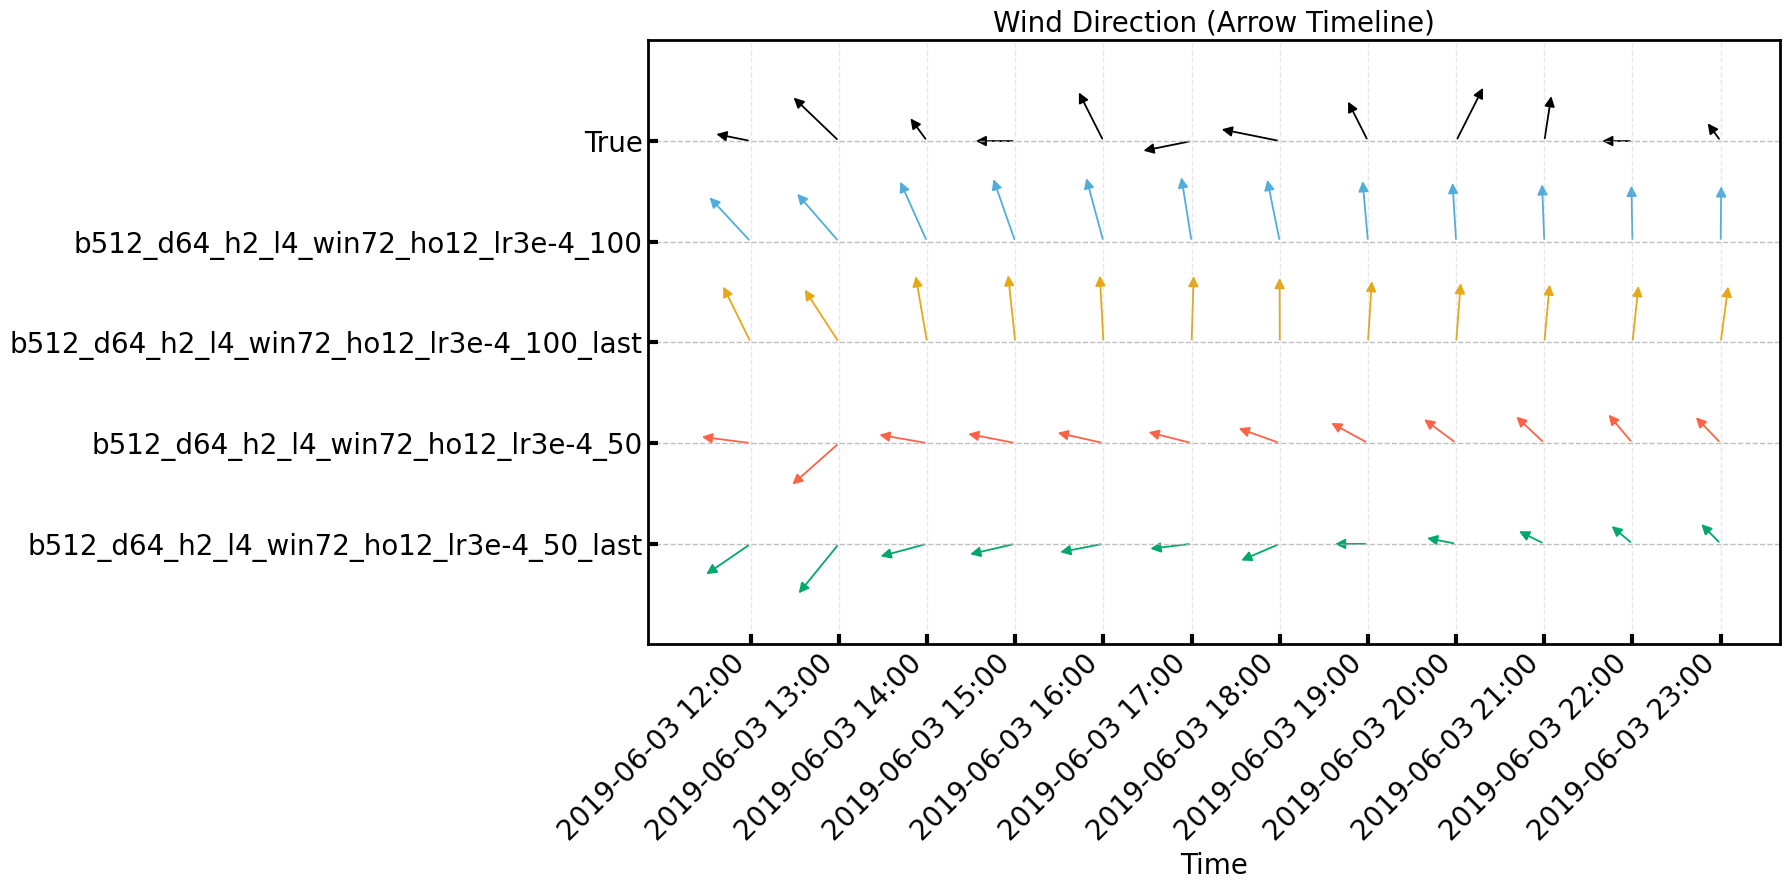

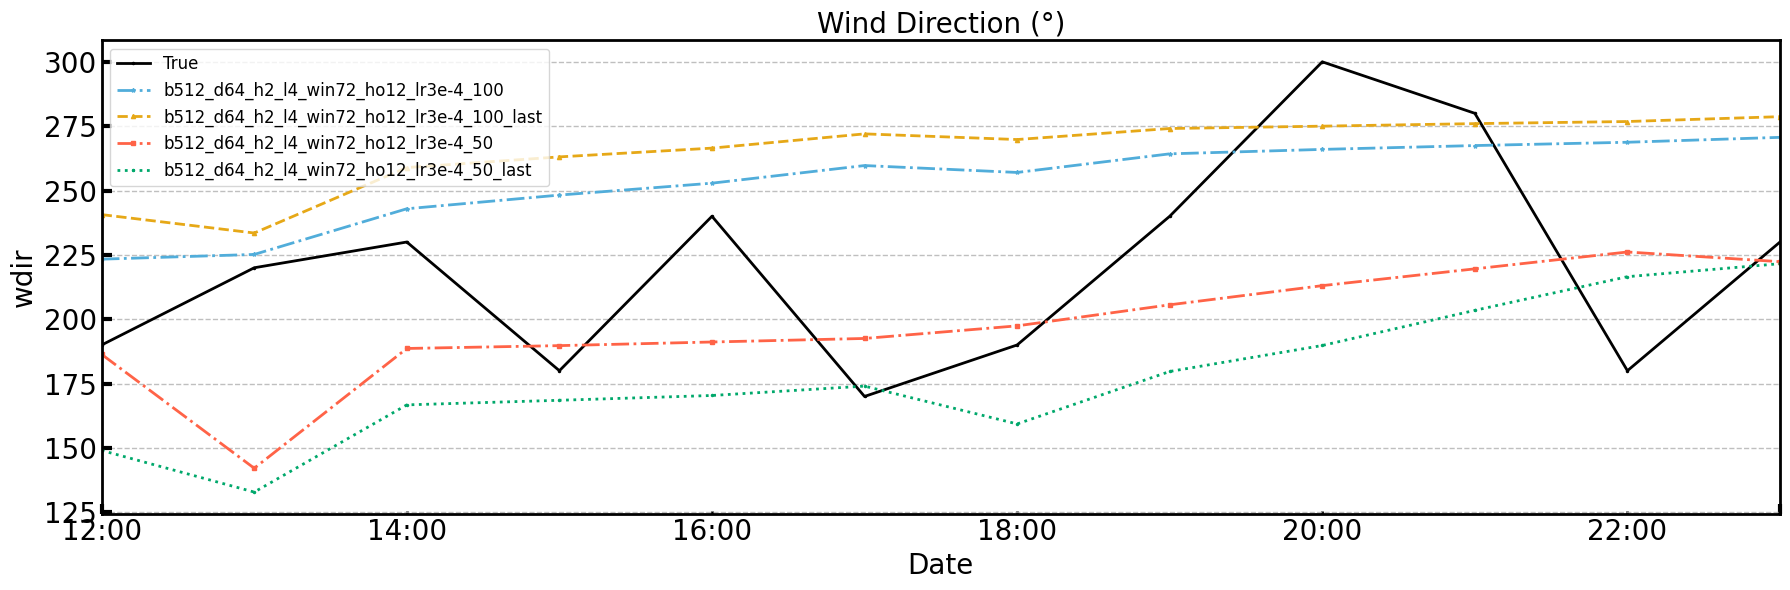

In [20]:
compare_models_per_feature(
    prediction_files_eftermiddag,
    features=['temp', 'rhum', 'wspd', 'wdir'],
    titles=['Temperature (°C)', 'Relative Humidity (%)', 'Wind Speed (km/h)', 'Wind Direction (°)'],
    start_time=datetime(2019, 6, 3, 12, 0)
)

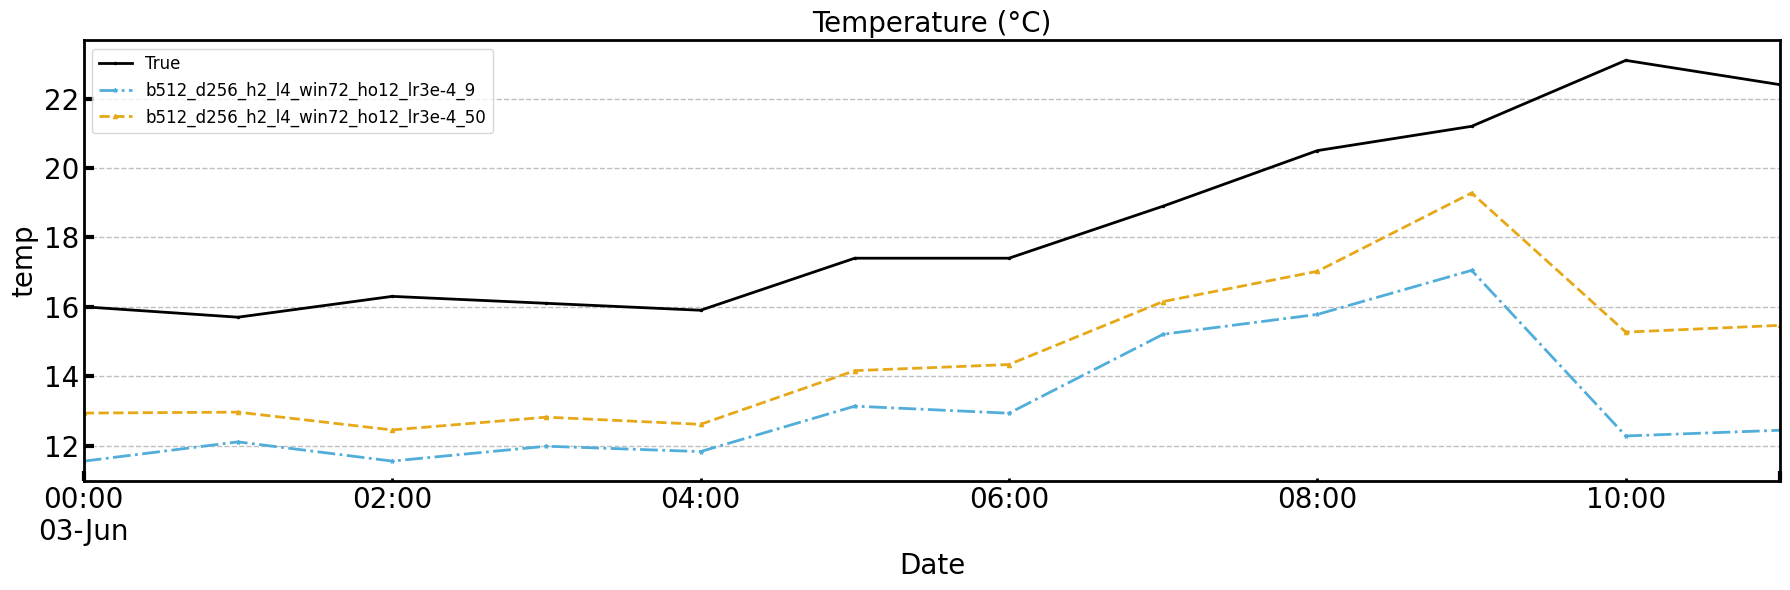

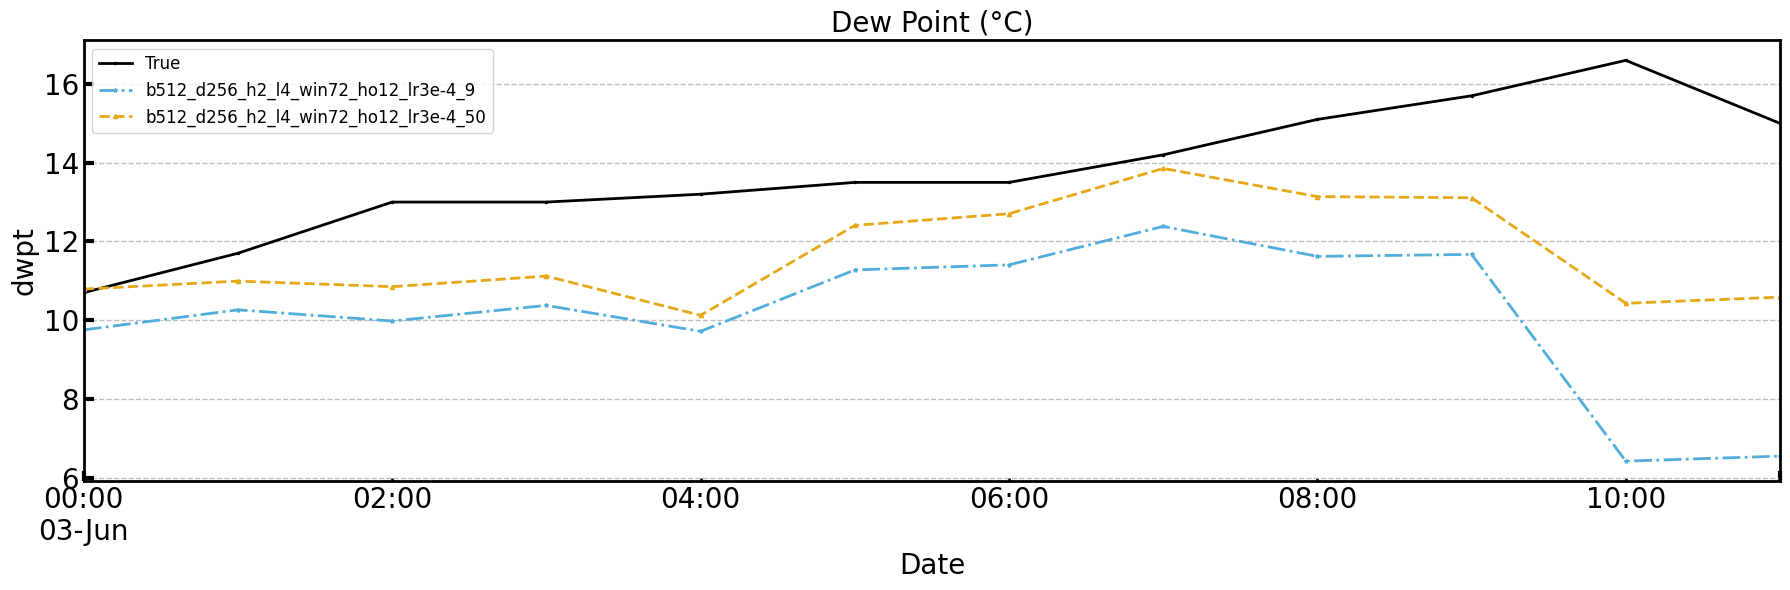

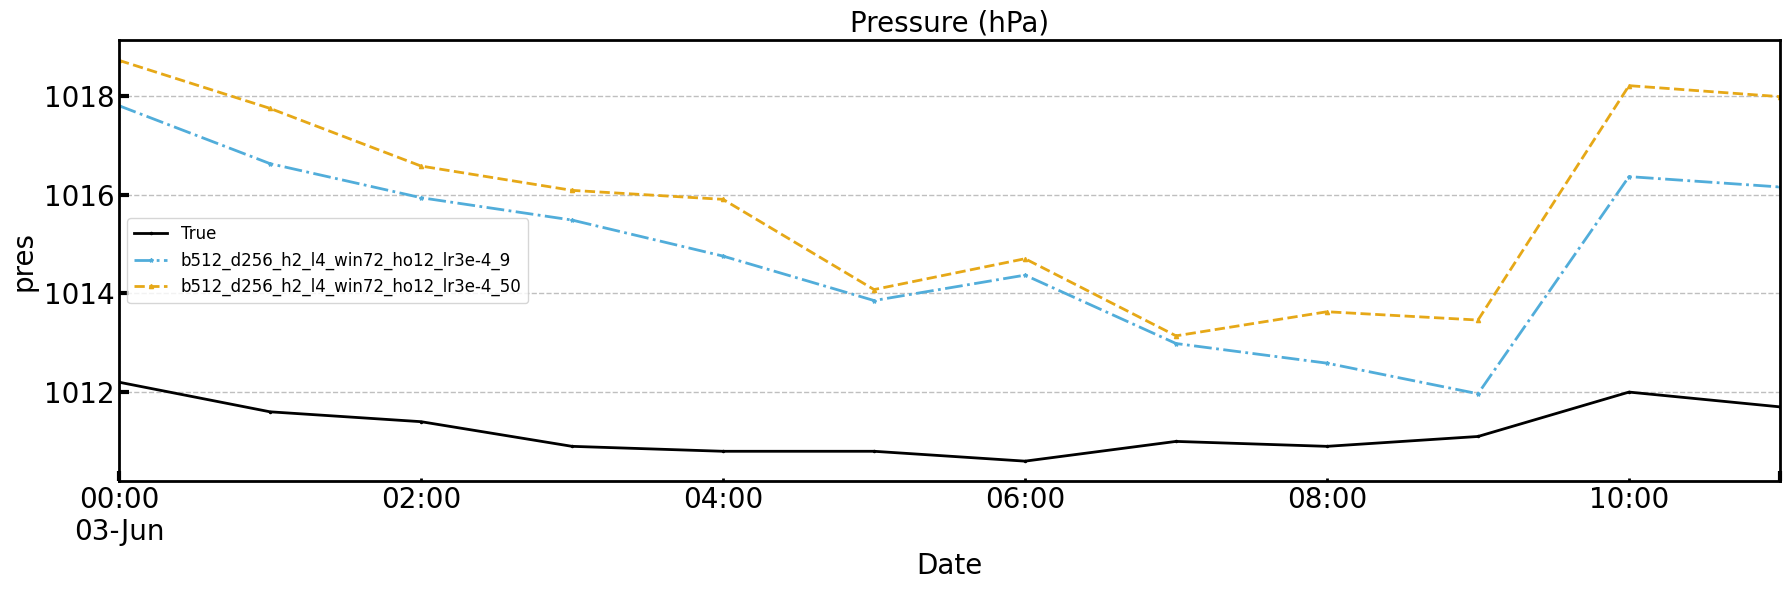

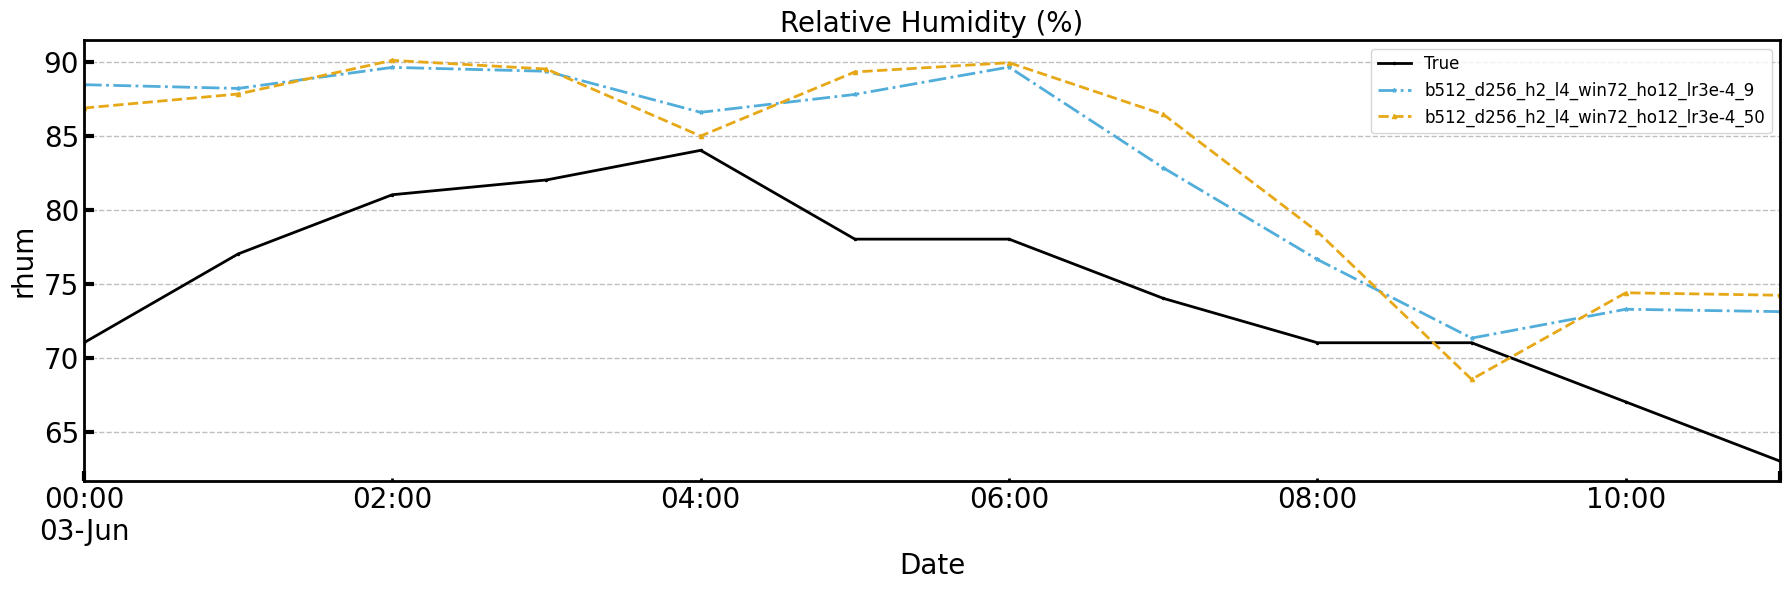

In [21]:
compare_models_per_feature(
    prediction_files_therm,
    # features=['temp', 'rhum', 'wspd', 'wdir'],
    features=['temp','dwpt','pres','rhum'],
    # titles=['Temperature (°C)', 'Relative Humidity (%)', 'Wind Speed (km/h)', 'Wind Direction (°)'],
    titles=['Temperature (°C)', 'Dew Point (°C)', 'Pressure (hPa)', 'Relative Humidity (%)'],
    start_time=datetime(2019, 6, 3, 0, 0)
)

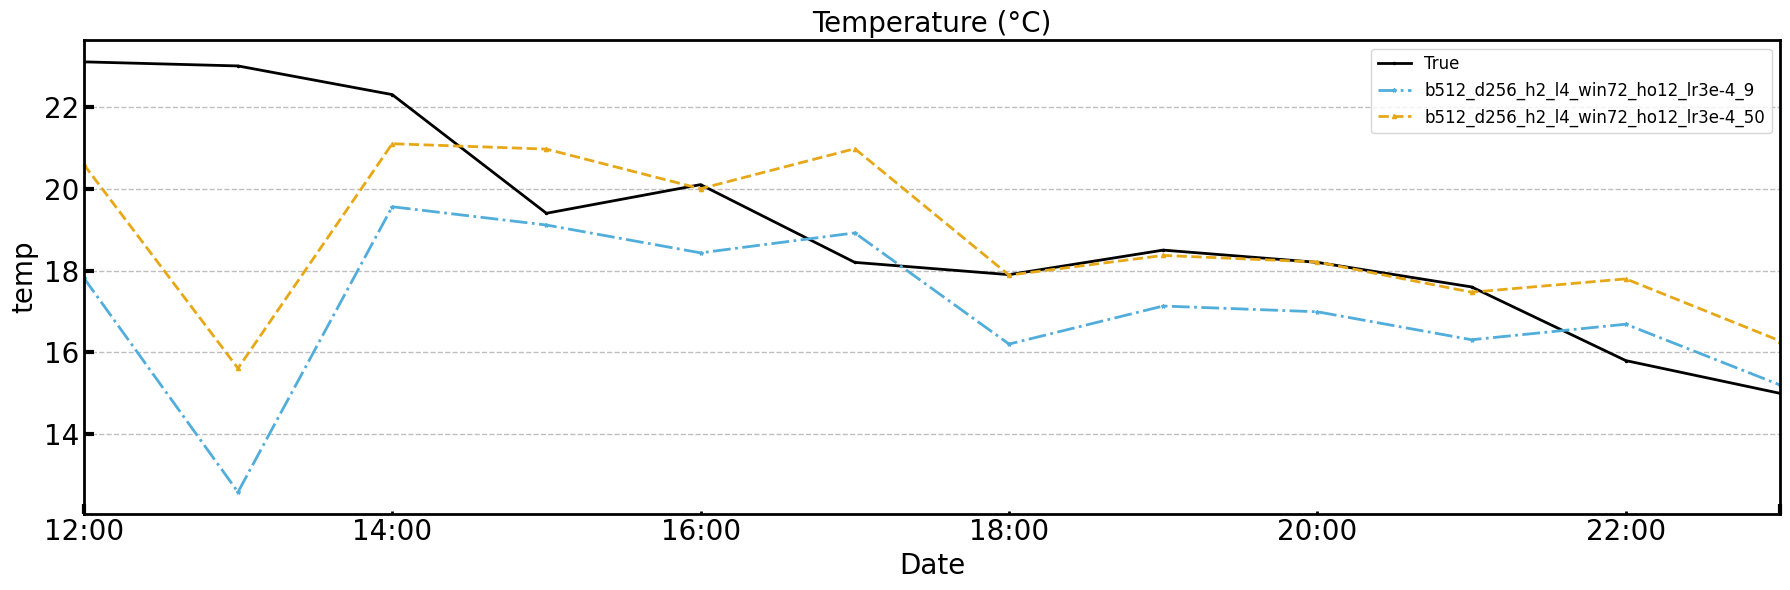

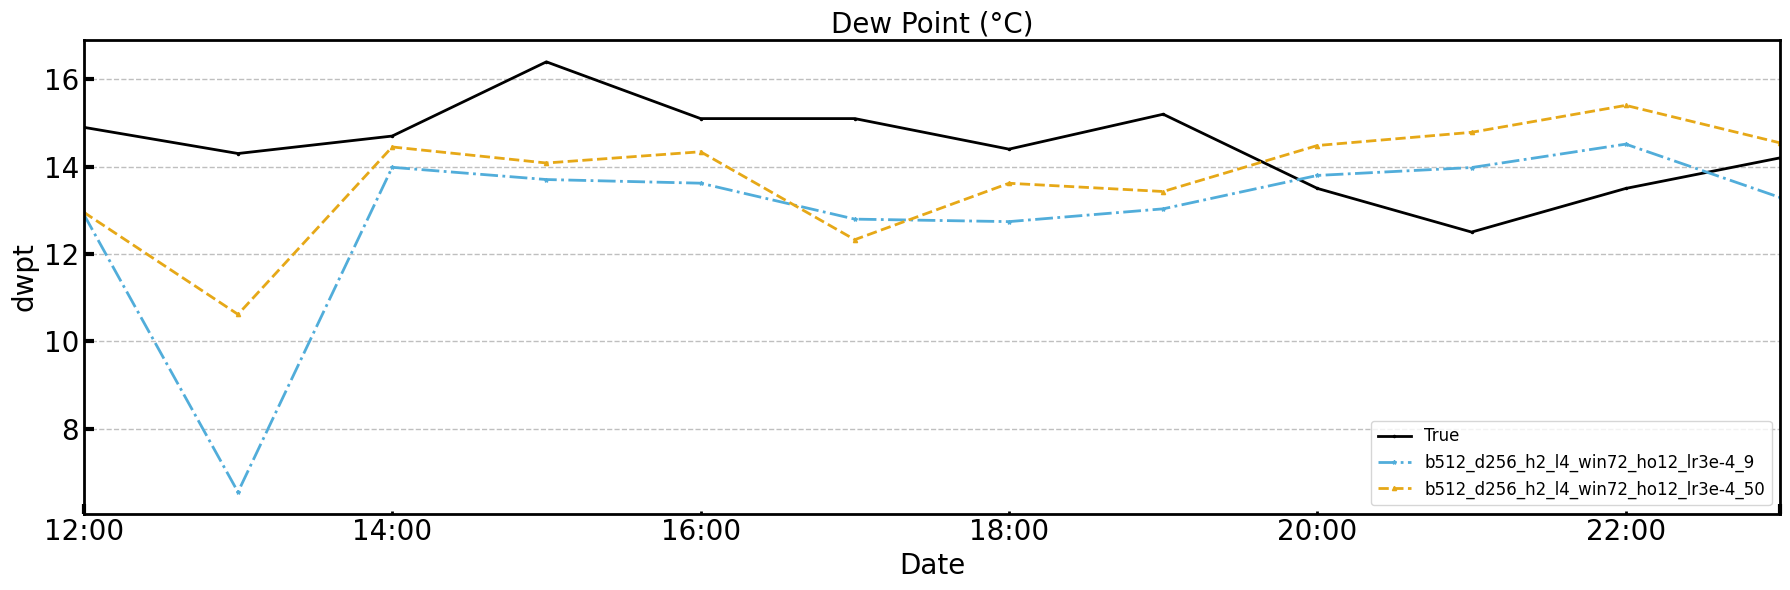

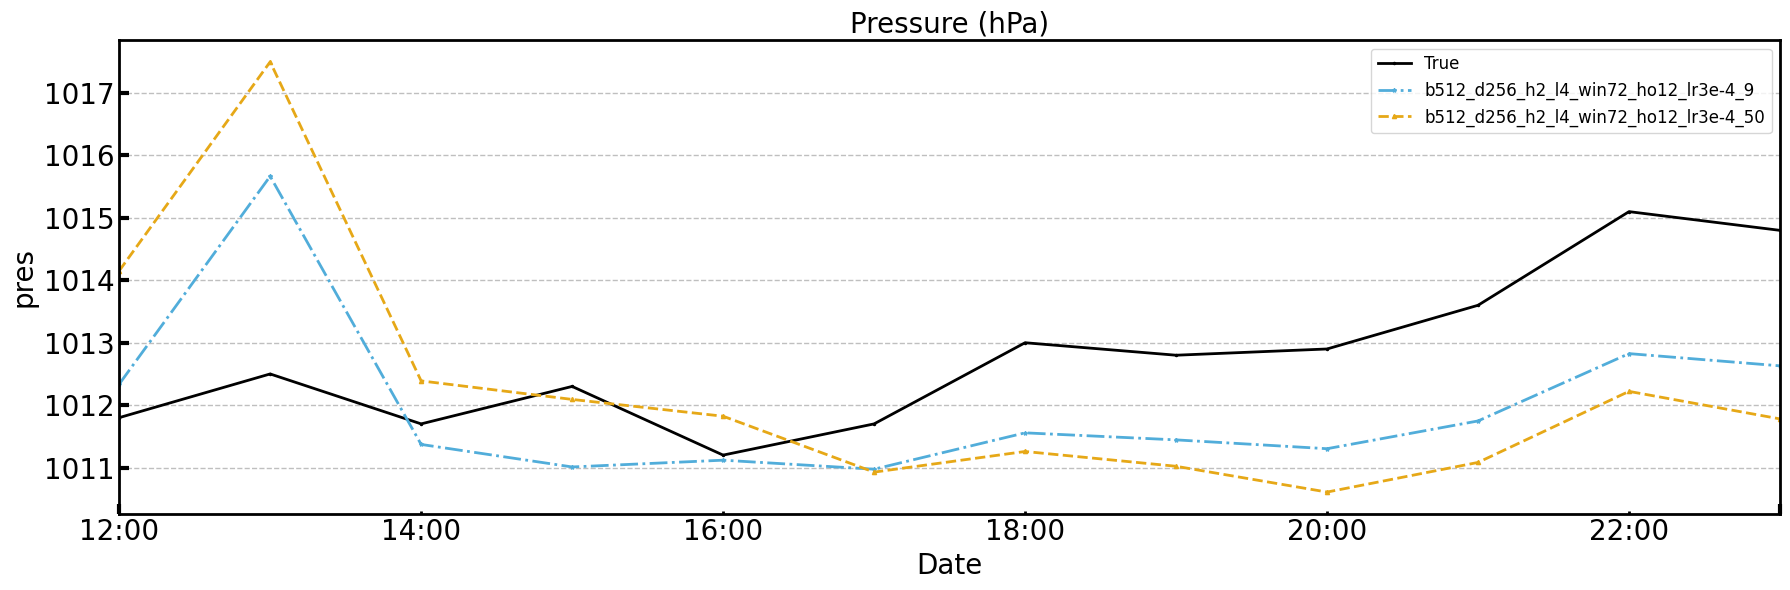

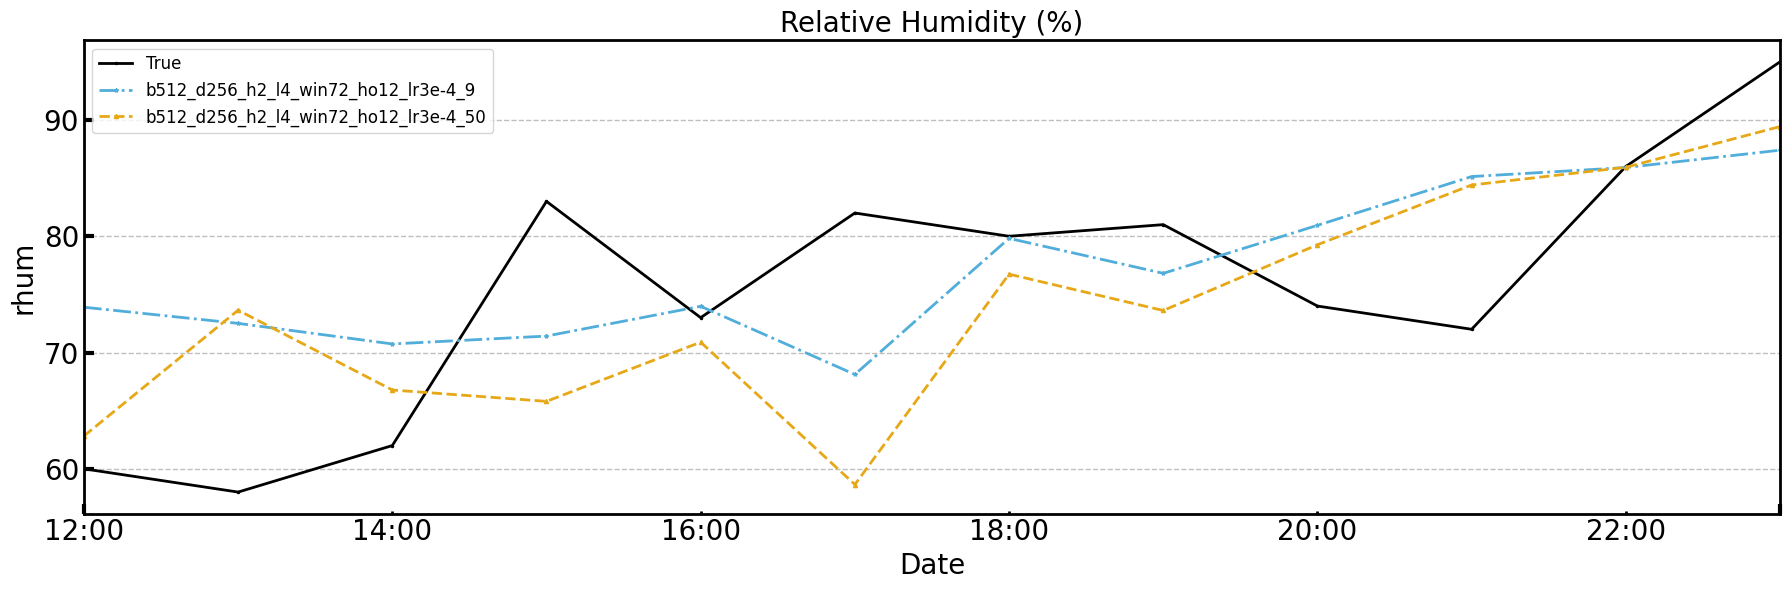

In [22]:
compare_models_per_feature(
    prediction_files_eftermiddag_therm,
    features=['temp','dwpt','pres','rhum'],
    titles=['Temperature (°C)', 'Dew Point (°C)', 'Pressure (hPa)', 'Relative Humidity (%)'],
    start_time = datetime(2019, 6, 3, 12, 0)
)

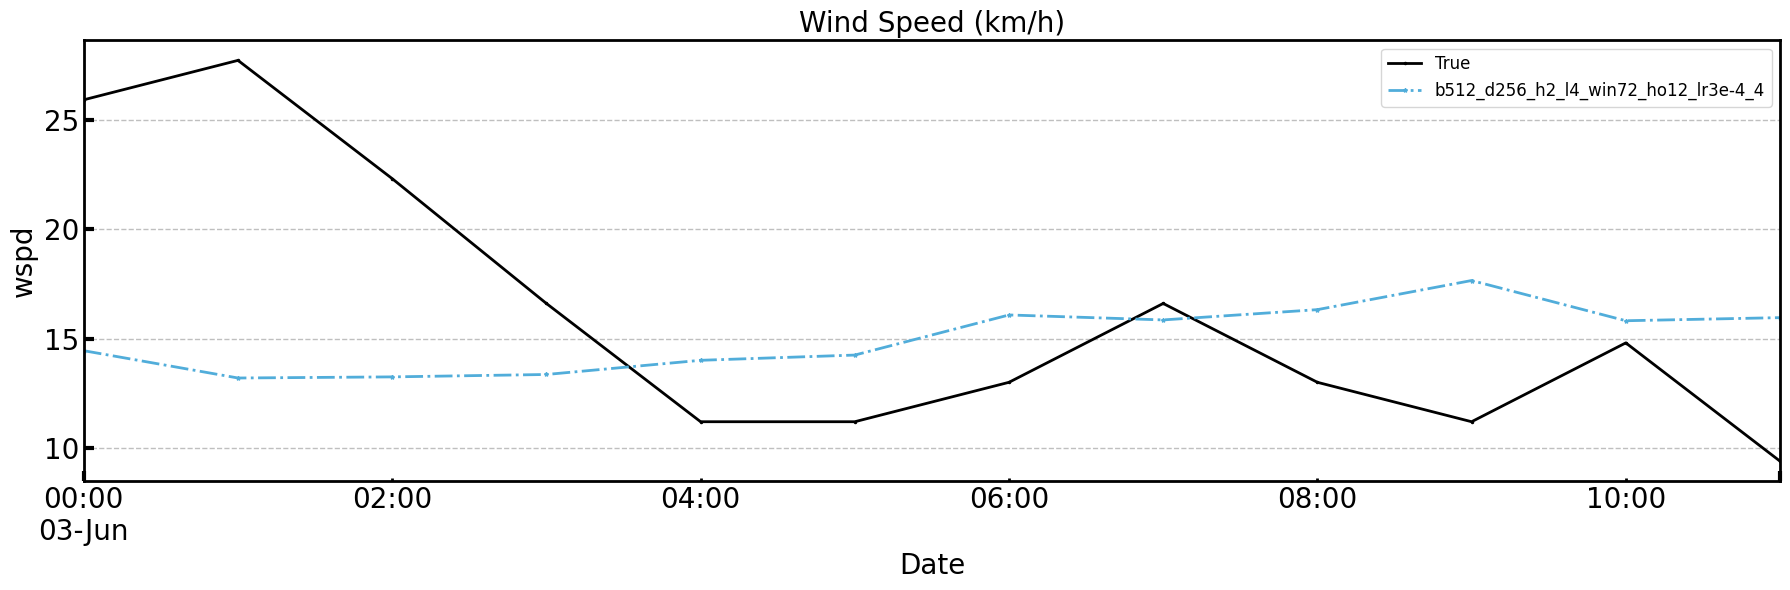

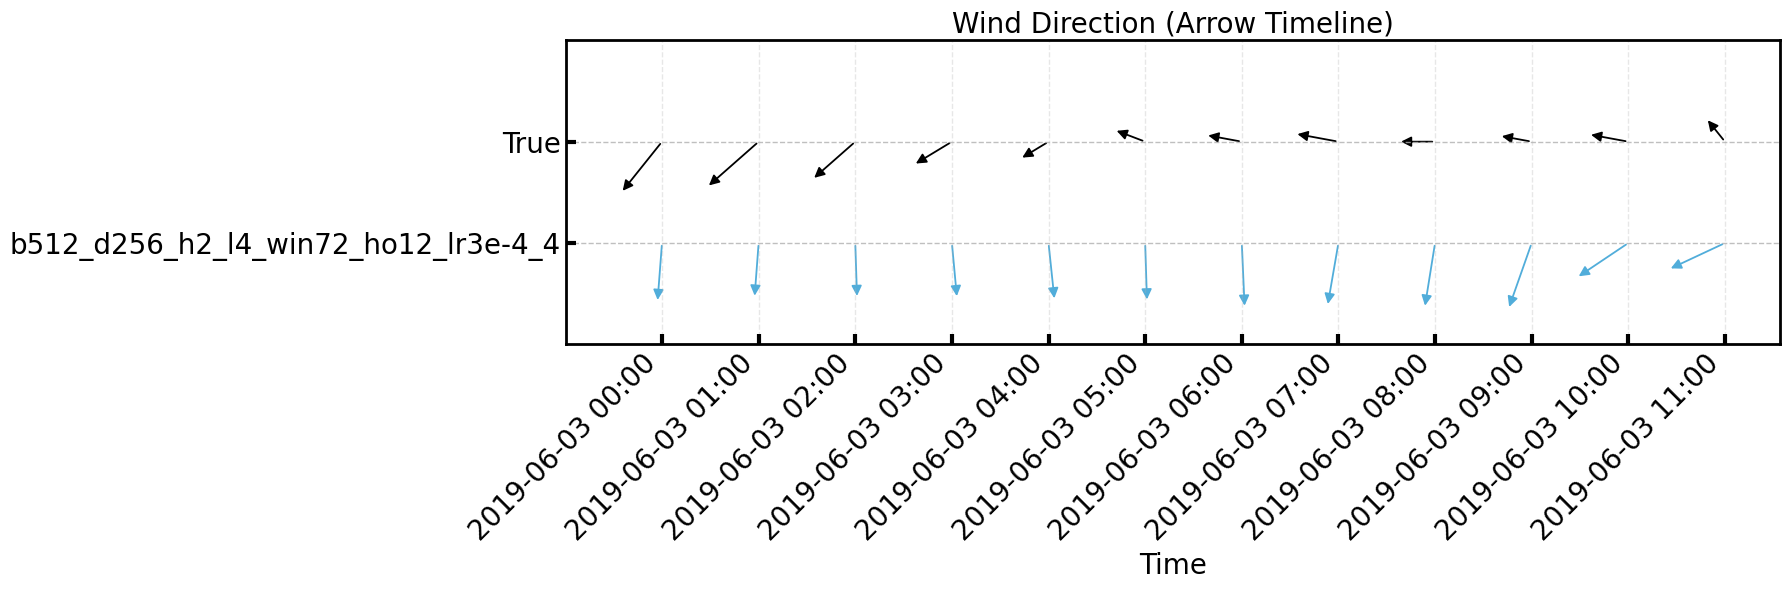

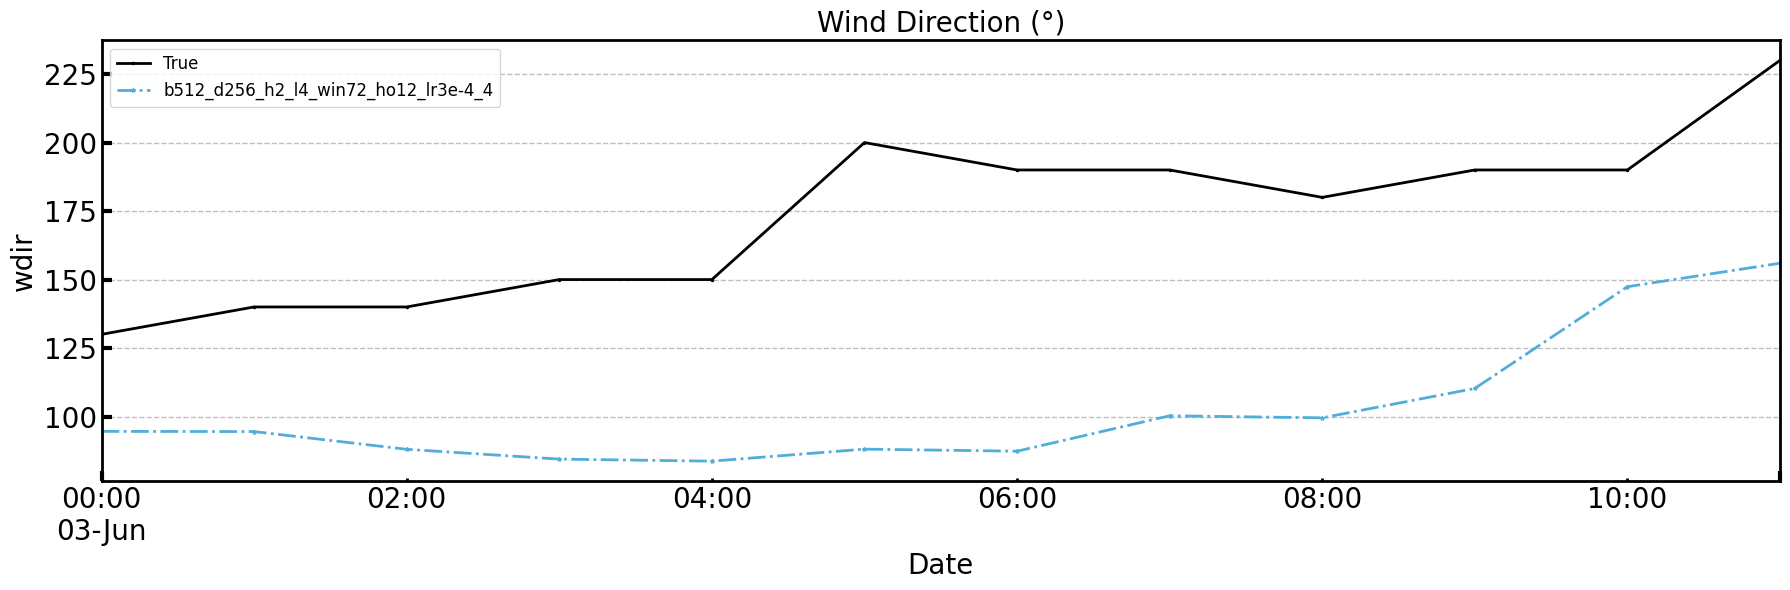

In [23]:
compare_models_per_feature(
    prediction_files_wind,
    features=['wspd', 'wdir'],
    titles=['Wind Speed (km/h)', 'Wind Direction (°)'],
    start_time=datetime(2019, 6, 3, 0, 0)
)

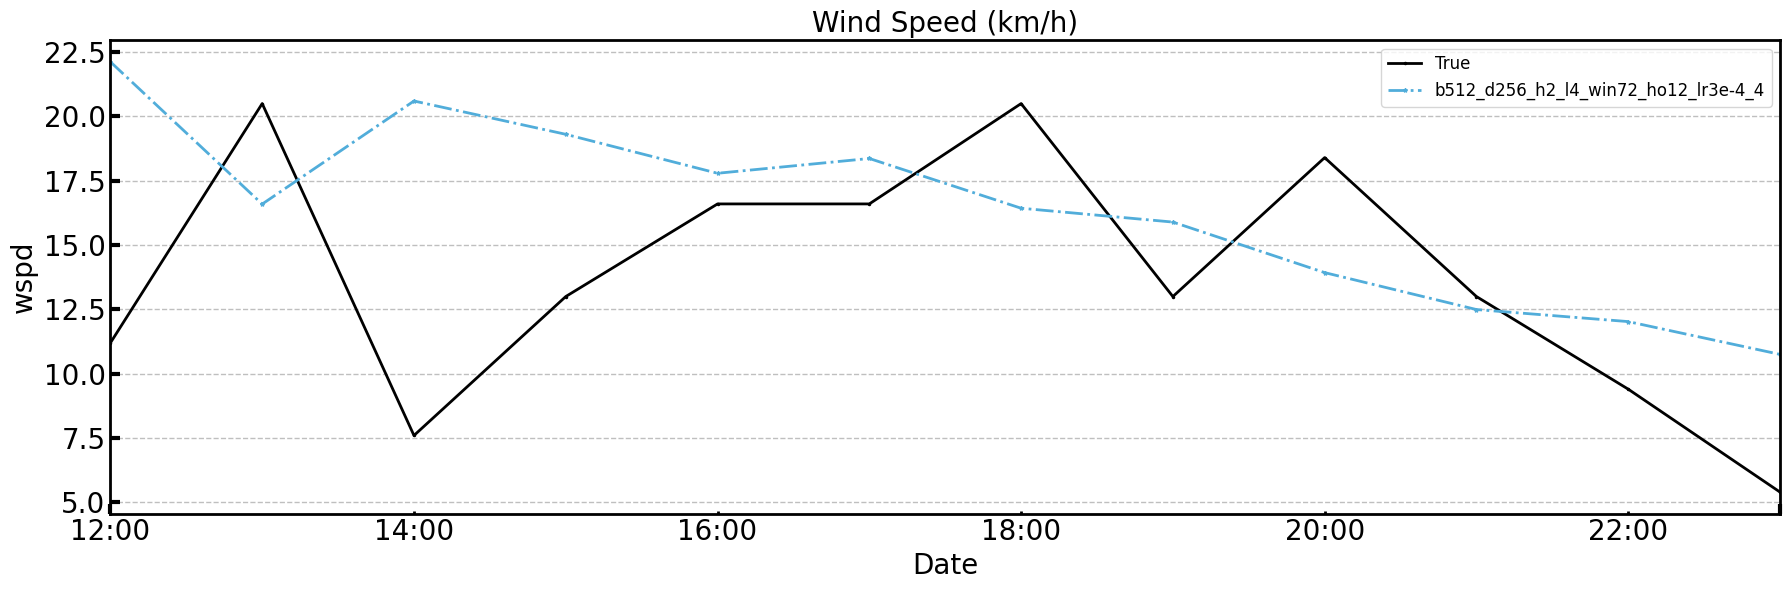

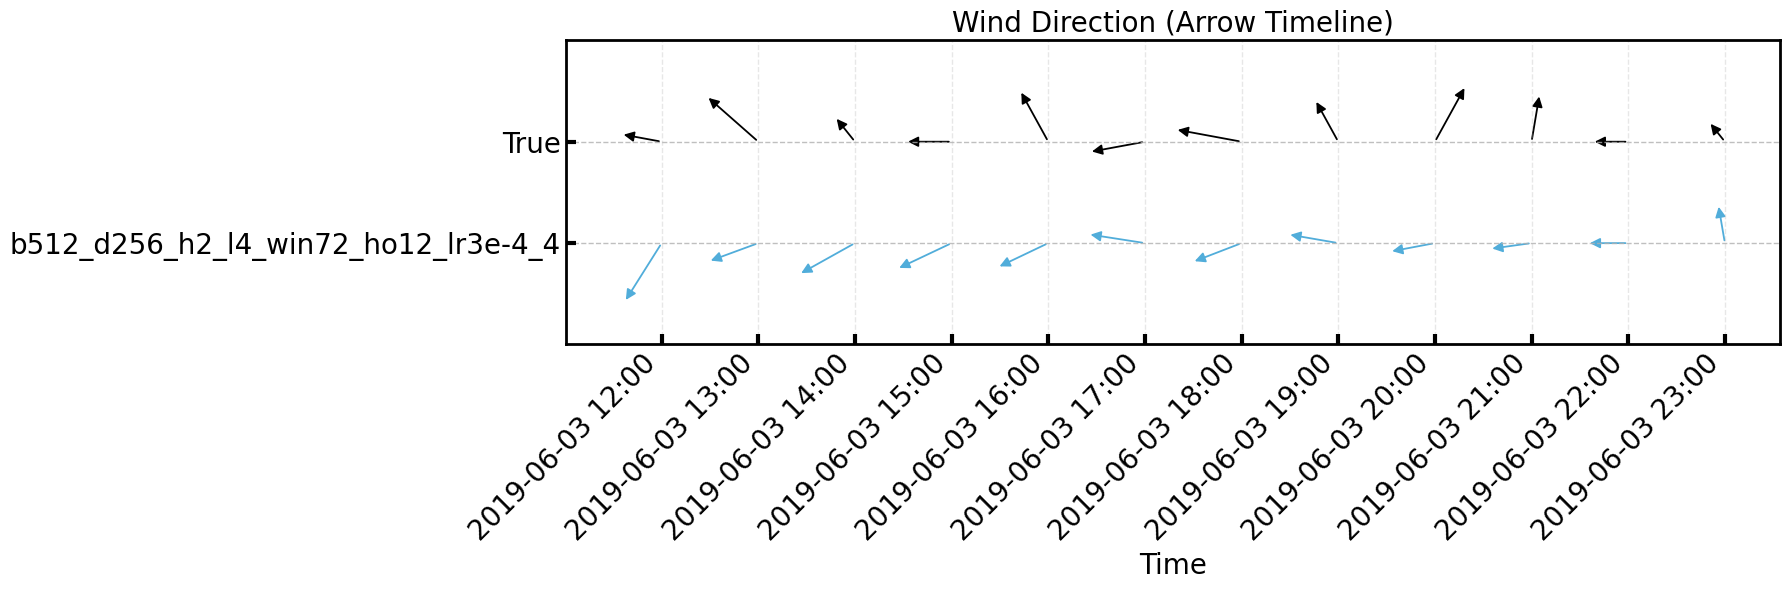

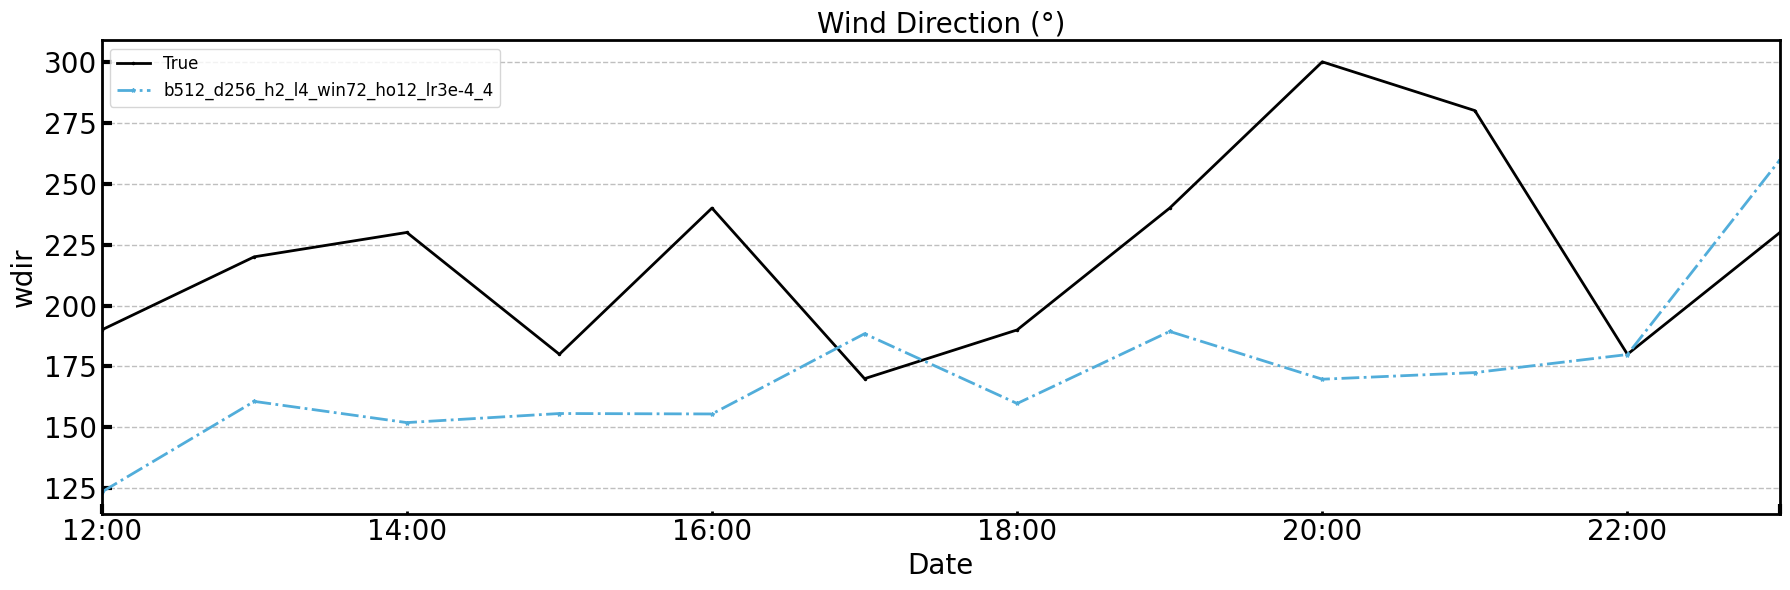

In [24]:
compare_models_per_feature(
    prediction_files_eftermiddag_wind,
    features=['wspd', 'wdir'],
    titles=['Wind Speed (km/h)', 'Wind Direction (°)'],
    start_time=datetime(2019, 6, 3, 12, 0)
)